In [ ]:
# =========================
# ACRS + Median + Watershed الكامل
# =========================

!pip install opencv-python-headless matplotlib scikit-image scipy

import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi

# =========================
# Step 1: Upload Image
# =========================
from google.colab import files
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = img.astype(np.float32)

# =========================
# Step 2: Extract RGB
# =========================
R = img[:, :, 0]
G = img[:, :, 1]
B = img[:, :, 2]

# Avoid division by zero
B_safe = B.copy()
B_safe[B_safe == 0] = 1

# =========================
# Step 3: Compute Ratios
# =========================
G2B = G / B_safe
R2B = R / B_safe

# =========================
# Step 4: Adaptive Threshold (CORE CONTRIBUTION)
# =========================
G2Bmax = np.max(G2B)
R2Bmax = np.max(R2B)

# safer version for publication
if R2Bmax == 0:
    T = 0
else:
    T = G2Bmax / R2Bmax

print("Adaptive Threshold T =", T)

# =========================
# Step 5: ACRS Segmentation
# =========================
white_mask = (R == 255) & (G == 255) & (B == 255)

blast_mask = (
    (R <= B) &
    (G2B <= T) &
    (~white_mask)
)

binary = (blast_mask.astype(np.uint8)) * 255

# =========================
# Step 6: Median Filtering
# =========================
filtered = cv2.medianBlur(binary, 5)

# =========================
# Step 7: Morphological Processing
# =========================
kernel = np.ones((3,3), np.uint8)

opening = cv2.morphologyEx(filtered, cv2.MORPH_OPEN, kernel, iterations=2)
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# =========================
# Step 8: Distance Transform
# =========================
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

_, sure_fg = cv2.threshold(
    dist_transform,
    0.2 * dist_transform.max(),
    255,
    0
)

sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

# =========================
# Step 9: Marker Labelling
# =========================
_, markers = cv2.connectedComponents(sure_fg)

markers = markers + 1
markers[unknown == 255] = 0

# =========================
# Step 10: Watershed Segmentation
# =========================
img_uint8 = img.astype(np.uint8)
markers = cv2.watershed(img_uint8, markers)

# =========================
# Step 11: Final Extraction
# =========================
final_mask = markers > 1

final_result = np.zeros_like(img_uint8)
final_result[final_mask] = img_uint8[final_mask]

# =========================
# Step 12: Visualization
# =========================
plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
plt.title("Original Image")
plt.imshow(img_uint8)
plt.axis('off')

plt.subplot(2,3,2)
plt.title("ACRS Binary Mask")
plt.imshow(binary, cmap='gray')
plt.axis('off')

plt.subplot(2,3,3)
plt.title("Median Filter")
plt.imshow(filtered, cmap='gray')
plt.axis('off')

plt.subplot(2,3,4)
plt.title("Distance Transform")
plt.imshow(dist_transform, cmap='jet')
plt.axis('off')

plt.subplot(2,3,5)
plt.title("Watershed Boundaries")
boundary = img_uint8.copy()
boundary[markers == -1] = [255, 0, 0]
plt.imshow(boundary)
plt.axis('off')

plt.subplot(2,3,6)
plt.title("Final Segmented Cells")
plt.imshow(final_result)
plt.axis('off')

plt.show()

TypeError: 'NoneType' object is not subscriptable

In [ ]:
# =========================
# Step 13: Extract Individual Cells
# =========================

# Create folder to save cells
import os
output_dir = "cropped_cells"
os.makedirs(output_dir, exist_ok=True)

cell_count = 0

# Loop through each unique marker (each cell)
for label in np.unique(markers):

    # Skip background and boundary
    if label <= 1:
        continue

    # Create mask for this cell
    cell_mask = (markers == label)

    # Convert to uint8
    cell_mask_uint8 = (cell_mask.astype(np.uint8)) * 255

    # Find contours
    contours, _ = cv2.findContours(
        cell_mask_uint8,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)

        # Filter very small noise regions
        if w < 20 or h < 20:
            continue

        # Crop original image
        cropped = img_uint8[y:y+h, x:x+w]

        # Optional: mask background inside crop
        mask_crop = cell_mask_uint8[y:y+h, x:x+w]
        cropped_masked = cv2.bitwise_and(cropped, cropped, mask=mask_crop)

        # Save image
        filename = f"{output_dir}/cell_{cell_count}.png"
        cv2.imwrite(filename, cv2.cvtColor(cropped_masked, cv2.COLOR_RGB2BGR))

        cell_count += 1

print(f"Total cells extracted: {cell_count}")

Total cells extracted: 12


In [ ]:
cropped_resized = cv2.resize(cropped_masked, (150, 150))

In [ ]:
cv2.imwrite(filename, cv2.cvtColor(cropped_resized, cv2.COLOR_RGB2BGR))

True

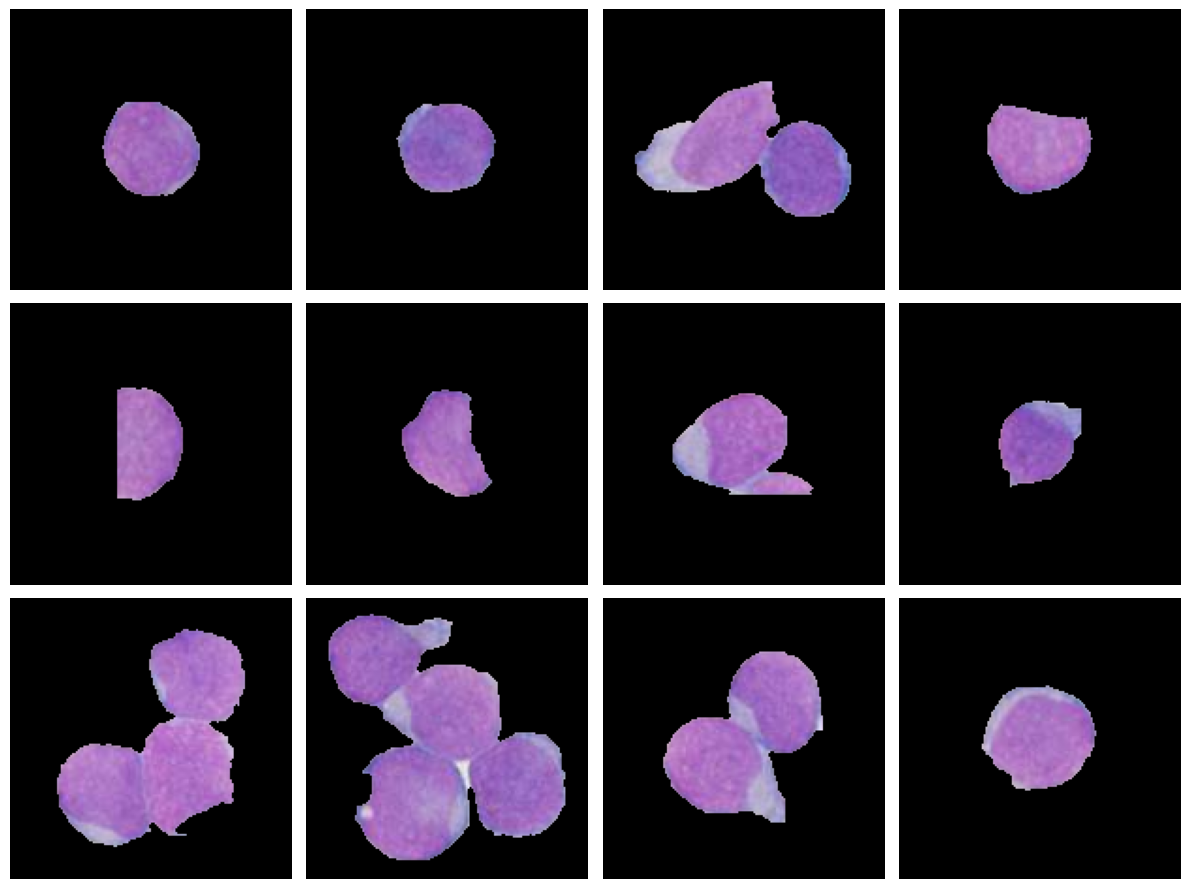

In [ ]:
import glob
import math

files = glob.glob("cropped_cells/*.png")[:cell_count]

# Dynamically calculate rows and columns for the subplot grid
num_images = len(files)
ncols = 4 # Number of columns to display
nrows = math.ceil(num_images / ncols)

plt.figure(figsize=(ncols * 3, nrows * 3)) # Adjust figure size based on grid
for i, f in enumerate(files):
    img_cell = cv2.imread(f)
    img_cell = cv2.cvtColor(img_cell, cv2.COLOR_BGR2RGB)

    plt.subplot(nrows, ncols, i+1)
    plt.imshow(img_cell)
    plt.axis('off')

plt.tight_layout() # Adjust layout to prevent overlapping titles
plt.show()

In [ ]:
# =========================
# Step 13: Extract + Pad Cells (NO distortion)
# =========================

import os
output_dir = "cropped_cells"
os.makedirs(output_dir, exist_ok=True)

TARGET_SIZE = 150  # your desired size

cell_count = 0

for label in np.unique(markers):

    if label <= 1:
        continue

    cell_mask = (markers == label)
    cell_mask_uint8 = (cell_mask.astype(np.uint8)) * 255

    contours, _ = cv2.findContours(
        cell_mask_uint8,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)

        # Remove tiny noise
        if w < 20 or h < 20:
            continue

        # Crop original image
        cropped = img_uint8[y:y+h, x:x+w]
        mask_crop = cell_mask_uint8[y:y+h, x:x+w]
        cropped_masked = cv2.bitwise_and(cropped, cropped, mask=mask_crop)

        # =========================
        # Create blank canvas
        # =========================
        canvas = np.zeros((TARGET_SIZE, TARGET_SIZE, 3), dtype=np.uint8)

        # Optional: use white background instead
        # canvas[:] = 255

        # =========================
        # Compute center placement
        # =========================
        y_offset = (TARGET_SIZE - h) // 2
        x_offset = (TARGET_SIZE - w) // 2

        # Safety (if cell larger than target)
        if h > TARGET_SIZE or w > TARGET_SIZE:
            scale = min(TARGET_SIZE / h, TARGET_SIZE / w)
            new_w = int(w * scale)
            new_h = int(h * scale)
            cropped_masked = cv2.resize(cropped_masked, (new_w, new_h))
            h, w = new_h, new_w
            y_offset = (TARGET_SIZE - h) // 2
            x_offset = (TARGET_SIZE - w) // 2

        # =========================
        # Paste into canvas
        # =========================
        canvas[y_offset:y_offset+h, x_offset:x_offset+w] = cropped_masked

        # Save
        filename = f"{output_dir}/cell_{cell_count}.png"
        cv2.imwrite(filename, cv2.cvtColor(canvas, cv2.COLOR_RGB2BGR))

        cell_count += 1

print(f"Total cells extracted: {cell_count}")

Total cells extracted: 12
